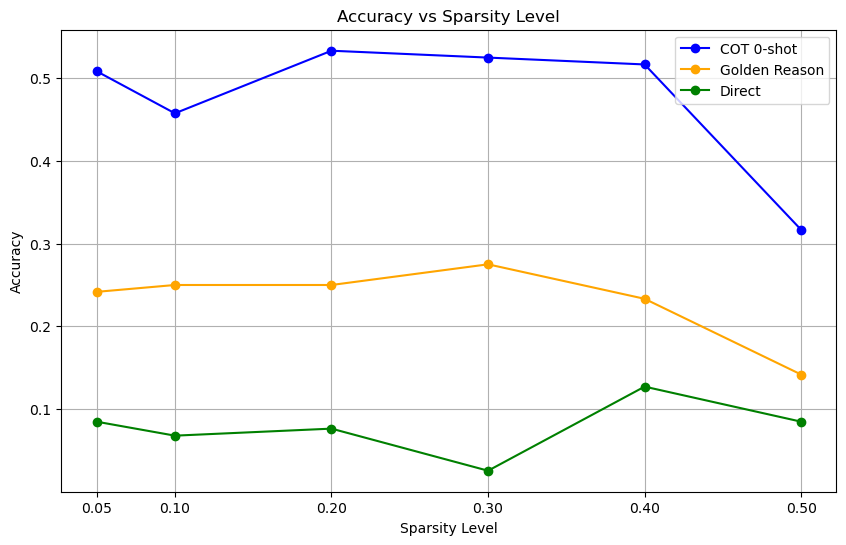

In [1]:
sparsity_levels = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
cot0shot_acc = [0.5085, 0.4576, 0.5333, 0.5250, 0.5167, 0.3167]
golden_reason_acc = [0.2417, 0.2500, 0.2500, 0.2750, 0.2333, 0.1417]
direct_acc = [0.0847, 0.0678, 0.0763, 0.0254, 0.1271, 0.0847]
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.plot(sparsity_levels, cot0shot_acc, marker='o', label='COT 0-shot', color='blue')
plt.plot(sparsity_levels, golden_reason_acc, marker='o', label='Golden Reason', color='orange')
plt.plot(sparsity_levels, direct_acc, marker='o', label='Direct', color='green')
plt.xlabel('Sparsity Level')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Sparsity Level')
plt.xticks(sparsity_levels)
plt.grid(True)
plt.legend()

In [8]:
prune_data_options = ["GSM8K_direct_120", "GSM8K_cot0shot_120", "GSM8K_cot0shot_goldreason"]
sparsity_ratios = [0, 0.03, 0.06, 0.09, 0.12, 0.15]
prune_method_options = ["random", "wanda"]
prompt_methods = ["direct", "cot0shot", "cot0shot_goldreason"]
model = "llama2-7b-chat-hf"  # 可改为变量
sparsity_type = "unstructured"  # 也可以设为参数

import os
from pathlib import Path

# 记录最终结果
summary_lines = []

# 遍历所有组合
for prune_data in prune_data_options:
    for prune_method in prune_method_options:
        for sparsity_ratio in sparsity_ratios:
            for prompt_method in prompt_methods:
                suffix = f"weightonly"
                save_dir = f"/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/{model}/{sparsity_type}/{prune_method}_{suffix}/{prune_data}/sparsity_{sparsity_ratio}"
                log_file = os.path.join(save_dir, f"log_{prune_method}.txt")
# /common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/llama2-7b-chat-hf/unstructured
                if not os.path.exists(log_file):
                    continue

                # 读取 log 文件，查找带 held_out 的最新一行
                with open(log_file, "r") as f:
                    lines = f.readlines()

                held_out_lines = [line.strip() for line in lines if "held_out" in line]
                if held_out_lines:
                    summary_lines.append(held_out_lines[-1])  # 最后一条 held_out 结果

# 保存所有 held_out 结果汇总
output_txt = "held_out_summary.txt"
with open(output_txt, "w") as out:
    for line in summary_lines:
        out.write(line + "\n")

print(f"共记录 {len(summary_lines)} 条 held-out 结果，已写入 {output_txt}")


共记录 15 条 held-out 结果，已写入 held_out_summary.txt


In [3]:
import os
from pathlib import Path

prune_data_options   = ["GSM8K_direct_120", "GSM8K_cot0shot_120", "GSM8K_cot0shot_goldreason"]
sparsity_ratios      = [0, 0.03, 0.06, 0.09, 0.12, 0.15]
prune_method_options = ["random", "wanda"]
prompt_methods       = ["direct", "cot0shot", "cot0shot_goldreason"]

model         = "llama2-7b-chat-hf"
sparsity_type = "unstructured"
suffix        = "weightonly"

summary_lines = []          # 收集所有最新结果

for prune_data in prune_data_options:
    for prune_method in prune_method_options:
        for sparsity_ratio in sparsity_ratios:

            save_dir = (
                f"/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/"
                f"out/{model}/{sparsity_type}/{prune_method}_{suffix}/"
                f"{prune_data}/sparsity_{sparsity_ratio}"
            )
            log_file = os.path.join(save_dir, f"log_{prune_method}.txt")
            if not os.path.exists(log_file):
                continue

            # 读取一次日志，随后按 prompt_method 过滤
            with open(log_file, "r") as f:
                lines = [ln.strip() for ln in f.readlines()]

            for pm in prompt_methods:
                # 同时包含 “held_out” 和该 prompt_method 的行
                pm_lines = [ln for ln in lines if "held_out" in ln and pm in ln]
                if pm_lines:
                    summary_lines.append(pm_lines[-1])   # 最新一行

# 去重（可选，防止意外重复）
summary_lines = list(dict.fromkeys(summary_lines))

# 写出汇总
output_txt = "held_out_summary_latest3.txt"
with open(output_txt, "w") as out:
    out.write("\n".join(summary_lines))

print(f"已记录 {len(summary_lines)} 条最新 held-out 结果，写入 {output_txt}")


已记录 56 条最新 held-out 结果，写入 held_out_summary_latest3.txt


In [ ]:
import os

prune_data_options   = ["GSM8K_direct_120", "GSM8K_cot0shot_120", "GSM8K_cot0shot_goldreason"]
sparsity_ratios      = [0, 0.03, 0.06, 0.09, 0.12, 0.15]
prune_method_options = ["random", "wanda"]
prompt_methods       = ["direct", "cot0shot", "cot0shot_goldreason"]

model         = "llama2-7b-chat-hf"
sparsity_type = "unstructured"
suffix        = "weightonly"

summary = []                    # 收集结果行

for prune_data in prune_data_options:
    for prune_method in prune_method_options:
        for sparsity_ratio in sparsity_ratios:

            save_dir = (
                f"/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/"
                f"out/{model}/{sparsity_type}/{prune_method}_{suffix}/"
                f"{prune_data}/sparsity_{sparsity_ratio}"
            )
            log_path = os.path.join(save_dir, f"log_{prune_method}.txt")
            if not os.path.exists(log_path):
                continue

            # 读取一次整个文件
            with open(log_path, "r") as f:
                lines = [ln.rstrip("\n") for ln in f]

            # 为每种 prompt_method 找“最新”（最后出现）的 held_out 行
            for pm in prompt_methods:
                latest = None
                for ln in reversed(lines):                 # 倒序遍历 → 第一条即最新
                    cols = ln.split("\t")
                    if len(cols) < 7:
                        continue
                    if cols[4] == pm and cols[5] == "held_out" and cols[2] == "True":
                        latest = ln
                        break
                    
                if latest:
                    summary.append(latest)

# 去重（防重复写入）
summary = list(dict.fromkeys(summary))

out_file = "held_out_summary_latest_by_prompt.txt"
with open(out_file, "w") as f:
    f.write("\n".join(summary))

print(f"已提取 {len(summary)} 行最新 held_out 结果 → {out_file}")


已提取 13 行最新 held_out 结果 → held_out_summary_latest_by_prompt.txt


/tmp/ipykernel_2684293/1964671580.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_combos))


[警告] random 无数据


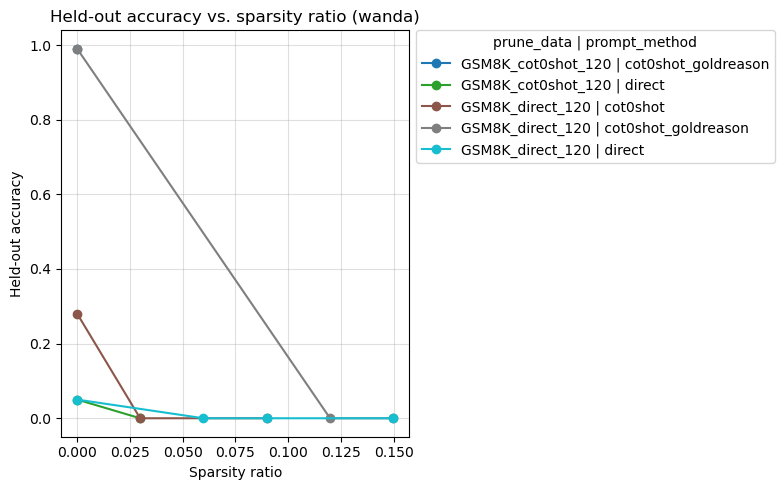

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- 配置 ----------------
# >>> 把下面路径替换成你的实际文件位置（或把脚本放到同目录） <<<
txt_path = Path("held_out_summary_latest_by_prompt.txt")

if not txt_path.exists():
    raise FileNotFoundError(f"文件 {txt_path} 不存在，请确认路径正确")

# ---------------- 读取数据 ----------------
df = pd.read_csv(
    txt_path,
    sep="\t",
    header=None,
    names=[
        "prune_method",
        "sparsity_ratio",
        "neg_prune",
        "prune_data",
        "prompt_method",
        "eval_type",
        "accuracy",
    ],
)

# 仅保留 held_out 行
df = df[df["eval_type"] == "held_out"].copy()
df.sort_values(["prune_data", "prompt_method", "sparsity_ratio"], inplace=True)

# 组合标签：prune_data + prompt_method
df["combo"] = df["prune_data"] + " | " + df["prompt_method"]


# ---------------- 构建全局颜色映射 ----------------
unique_combos = sorted(df["combo"].unique())
cmap = plt.cm.get_cmap("tab10", len(unique_combos))
combo2color = {combo: cmap(i) for i, combo in enumerate(unique_combos)}

# ---------------- 绘图函数 ----------------
def plot_by_prune_method(method: str, data: pd.DataFrame, combo_colors: dict):
    sub = data[data["prune_method"] == method]
    if sub.empty:
        print(f"[警告] {method} 无数据")
        return

    plt.figure(figsize=(8, 5))
    for combo, grp in sub.groupby("combo"):
        plt.plot(
            grp["sparsity_ratio"],
            grp["accuracy"],
            marker="o",
            label=combo,
            color=combo_colors[combo],
        )

    plt.xlabel("Sparsity ratio")
    plt.ylabel("Held‑out accuracy")
    plt.title(f"Held‑out accuracy vs. sparsity ratio ({method})")
    plt.grid(alpha=0.4)
    plt.legend(
        title="prune_data | prompt_method",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
    )
    plt.tight_layout()
    plt.show()

# ---------------- 生成两张图，颜色一致 ----------------
plot_by_prune_method("random", df, combo2color)
plot_by_prune_method("wanda",  df, combo2color)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- 路径：请按需修改 ----------------
txt_path = Path("held_out_summary_latest_by_prompt.txt")
if not txt_path.exists():
    raise FileNotFoundError(f"找不到 {txt_path} ，请确认路径正确")

# ---------------- 读取数据 ------------------------
df = pd.read_csv(
    txt_path,
    sep="\t",
    header=None,
    names=[
        "prune_method",
        "sparsity_ratio",
        "neg_prune",
        "prune_data",
        "prompt_method",
        "eval_type",
        "accuracy",
    ],
)

# 仅 held_out
df = df[df["eval_type"] == "held_out"].copy()
df["combo"] = df["prune_data"] + " | " + df["prompt_method"]

# ---------------- 透视表：random vs wanda ----------------
pivot = df.pivot_table(
    index=["sparsity_ratio", "combo"],
    columns="prune_method",
    values="accuracy",
)

# 计算 wanda 相对 random 的下降百分比
pivot["drop_pct"] = (pivot["wanda"] - pivot["random"]) / pivot["random"] * 100
pivot = pivot.dropna(subset=["drop_pct"]).reset_index()


# ---------------- 颜色映射 ----------------
combos = sorted(pivot["combo"].unique())
cmap   = plt.cm.get_cmap("tab10", len(combos))
combo2color = {c: cmap(i) for i, c in enumerate(combos)}

# ---------------- 绘图 --------------------
plt.figure(figsize=(8, 5))
for combo, grp in pivot.groupby("combo"):
    plt.plot(
        grp["sparsity_ratio"],
        grp["drop_pct"],
        marker="o",
        color=combo2color[combo],
        label=combo,
    )

plt.xlabel("Sparsity ratio")
plt.ylabel("Accuracy drop of Wanda vs. Random (%)")
plt.title("Relative accuracy drop (Wanda vs. Random)")
plt.grid(alpha=0.4)
plt.legend(title="prune_data | prompt_method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


KeyError: 'random'

In [20]:
pivot

prune_method,sparsity_ratio,combo,random,wanda,drop_pct
0,0.0,GSM8K_cot0shot_120 | cot0shot,0.28,0.28,0.0
1,0.0,GSM8K_cot0shot_120 | cot0shot_goldreason,0.99,0.99,0.0
2,0.0,GSM8K_cot0shot_120 | direct,0.05,0.05,0.0
3,0.0,GSM8K_cot0shot_goldreason | cot0shot,0.28,0.28,0.0
4,0.0,GSM8K_cot0shot_goldreason | cot0shot_goldreason,0.99,0.99,0.0
5,0.0,GSM8K_direct_120 | cot0shot,0.28,0.28,0.0
6,0.0,GSM8K_direct_120 | cot0shot_goldreason,0.99,0.99,0.0
7,0.0,GSM8K_direct_120 | direct,0.05,0.05,0.0
